# One team, one model: a forecast walkthrough with gradient boosting

This notebook runs the WorkloadHub forecasting pipeline step by step for a single team, using the
**gradient boosting** arrival model (`gbm`) instead of the tournament, and then asks GitHub Copilot to
explain the result.

It uses the service's own functions, the same ones `whf run` and the desktop app call, so what you see
here is exactly what the product computes. The reference for every step is
`docs/design/2026-09-07-forecasting-internals.md`.

**How to run it.** From the `service/` folder, with the project installed (`uv sync`):

```powershell
uv run --with jupyter --with matplotlib jupyter lab ..\docs\notebooks\gbm-forecast-walkthrough.ipynb
```

- With no environment variable set, the notebook generates the sample data into a temporary
  database so it works anywhere. Set `WHF_NOTEBOOK_DB` to the path of a real database to use it instead.
- Section 6 needs the GitHub Copilot CLI installed and signed in (Settings page of the app, or
  `whf copilot login`). Without it the section prints why the narrative could not be produced and the
  rest of the notebook is unaffected.

## 1. Setup

Choose the database and the team. `TEAM_ID` is the team's id in the `teams` table; the cell below
lists them so you can pick.

In [1]:
import datetime as dt
import json
import os
import tempfile
from pathlib import Path

import pandas as pd

from whf.db.connection import connect
from whf.db.repo import read_df

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 40)

db_env = os.environ.get("WHF_NOTEBOOK_DB")
if db_env:
    DB_PATH = Path(db_env)
    print(f"using the database at {DB_PATH}")
else:
    from whf.data.generator import GeneratorConfig, generate
    from whf.data.loader import load_generated

    DB_PATH = Path(tempfile.gettempdir()) / "whf-notebook-demo.sqlite"
    if DB_PATH.exists():
        DB_PATH.unlink()
    data = generate(GeneratorConfig(seed=42, months=12))
    conn = connect(DB_PATH)
    load_generated(conn, data)
    conn.close()
    print(f"generated {len(data.tasks)} tasks for {len(data.members)} members into {DB_PATH}")

conn = connect(DB_PATH)
teams = read_df(conn, "SELECT t.id, t.name, d.name AS department, t.team_leader_id FROM teams t JOIN departments d ON d.id = t.department_id ORDER BY t.id")
teams

generated 6522 tasks for 48 members into /tmp/whf-notebook-demo.sqlite


,id,name,department,team_leader_id
0,1,Web Platform,Software Engineering,2
1,2,Mobile Apps,Software Engineering,7
2,3,Integration,Software Engineering,12
3,4,Data Engineering,Data & Analytics,20
4,5,BI & Reporting,Data & Analytics,26
5,6,Cloud Operations,Infrastructure & Support,34
6,7,Service Desk,Infrastructure & Support,41
7,8,Security,Infrastructure & Support,45


In [2]:
TEAM_ID = 1                      # pick a team id from the table above
AS_OF = dt.date(2026, 9, 3)      # the run date; the generated data ends on 2026-09-03
MODEL = "gbm"                    # the gradient boosting arrival model

## 2. Load the team's data from the database

`_load_frames` is what `run_forecast` calls: every table the forecast needs, with the date columns
parsed. The arrival models are trained on **every counted member in the database** (the feature
matrix is global) and the forecast is read for this team, so we load everything and then look at the
team's slice.

In [3]:
from whf.pipeline import _load_frames

frames = _load_frames(conn)
members = frames["members"]
tasks = frames["tasks"]

team_members = members[(members["team_id"] == TEAM_ID) & (members["counted_in_workload"] == 1)]
team_name = teams.set_index("id").loc[TEAM_ID, "name"]
print(f"team {TEAM_ID}: {team_name}, {len(team_members)} counted members")
team_members[["id", "name", "role", "active_from", "active_to"]]

team 1: Web Platform, 5 counted members


,id,name,role,active_from,active_to
1,2,Malak Sefrioui,team_leader,None,None
2,3,Ayoub Lahlou,member,None,None
3,4,Karim Alaoui,member,None,None
4,5,Nadia Lamrani,member,None,None
5,6,Fatima Zniber,member,None,None


In [4]:
mine = tasks[tasks["assignee_id"].isin(team_members["id"])]
summary = pd.DataFrame({
    "tasks": mine.groupby("assignee_id").size(),
    "open": mine[mine["completed_at"].isna()].groupby("assignee_id").size(),
    "estimated_hours": mine.groupby("assignee_id")["estimated_hours"].sum().round(1),
    "first_assigned": mine.groupby("assignee_id")["assigned_at"].min(),
    "last_assigned": mine.groupby("assignee_id")["assigned_at"].max(),
}).fillna({"open": 0}).astype({"open": int})
summary.index = summary.index.map(dict(zip(team_members["id"], team_members["name"])))
summary

,tasks,open,estimated_hours,first_assigned,last_assigned
assignee_id,,,,,
Malak Sefrioui,75,0,591.4,2025-09-02,2026-09-02
Ayoub Lahlou,149,0,1088.0,2025-09-01,2026-08-31
Karim Alaoui,181,0,1384.5,2025-09-01,2026-09-01
Nadia Lamrani,142,1,1188.1,2025-09-02,2026-09-03
Fatima Zniber,78,3,650.2,2025-09-01,2026-08-31


## 3. Process: the arrival series and the feature matrix

`weekly_arrivals` sums the estimated hours of the tasks assigned to each member per Monday-starting
week, with explicit zeros for empty weeks. `build_feature_matrix` then adds the lags, rolling
statistics, calendar, project and availability features, and the shifted targets. Both are wrapped in
`arrival_feature_matrix(frames, origin)`, where `origin` is the last complete week before the run date.

In [5]:
from whf.calendar import ONE_WEEK, forecast_weeks, last_complete_week
from whf.features import feature_columns
from whf.pipeline import arrival_feature_matrix

origin = last_complete_week(AS_OF)
f1, f2 = forecast_weeks(AS_OF)
h1 = (f1 - origin).days // 7
HORIZONS = (h1, h1 + 1)
print(f"run date {AS_OF}: origin {origin}, forecast weeks {f1} and {f2}, horizons {HORIZONS}")

arrivals, feat, weeks = arrival_feature_matrix(frames, origin)
print(f"arrival series: {len(weeks)} weeks x {arrivals['member_id'].nunique()} members = {len(arrivals)} rows")
print(f"feature matrix: {feat.shape[0]} rows x {feat.shape[1]} columns; a model at horizon {h1} sees {len(feature_columns(h1))} of them")

run date 2026-09-03: origin 2026-08-24, forecast weeks 2026-09-07 and 2026-09-14, horizons (2, 3)
arrival series: 52 weeks x 45 members = 2340 rows
feature matrix: 2340 rows x 46 columns; a model at horizon 2 sees 26 of them


In [6]:
# The last 13 weeks of the team's arrival series, in estimated hours.
recent = arrivals[arrivals["member_id"].isin(team_members["id"]) & (arrivals["week_start"] > origin - 13 * ONE_WEEK)]
table = recent.pivot(index="member_id", columns="week_start", values="est_hours")
table.index = table.index.map(dict(zip(team_members["id"], team_members["name"])))
table.columns = [w.strftime("%m-%d") for w in table.columns]
table.round(1)

,06-01,06-08,06-15,06-22,06-29,07-06,07-13,07-20,07-27,08-03,08-10,08-17,08-24
member_id,,,,,,,,,,,,,
Malak Sefrioui,28.5,31.6,4.4,7.7,0.0,0.0,8.6,0.0,0.0,21.5,0.0,0.0,11.6
Ayoub Lahlou,21.7,10.0,23.5,6.8,15.3,28.8,4.3,19.7,0.0,40.8,35.3,4.2,3.2
Karim Alaoui,34.5,35.6,80.4,2.9,6.5,20.5,41.4,30.0,8.1,18.5,0.0,17.1,19.7
Nadia Lamrani,29.3,25.7,0.0,0.0,21.4,26.9,15.0,40.7,4.4,11.9,9.0,0.0,0.0
Fatima Zniber,11.4,2.4,0.0,0.0,0.0,3.3,2.9,0.0,8.0,0.0,14.2,13.4,18.0


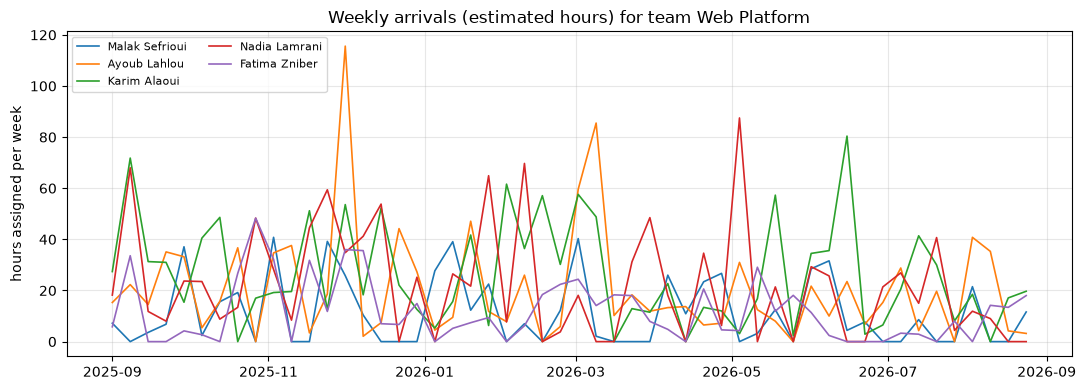

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11, 4))
for member_id, name in zip(team_members["id"], team_members["name"]):
    series = arrivals[arrivals["member_id"] == member_id].set_index("week_start")["est_hours"]
    ax.plot(series.index, series.values, label=name, linewidth=1.2)
ax.set_title(f"Weekly arrivals (estimated hours) for team {team_name}")
ax.set_ylabel("hours assigned per week")
ax.legend(loc="upper left", fontsize=8, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
# One member's feature row at the origin: what the model actually sees for horizon h1.
example_id = int(team_members["id"].iloc[0])
row = feat[(feat["member_id"].astype(int) == example_id) & (feat["week_start"] == origin)].iloc[0]
pd.DataFrame({"value": row[feature_columns(h1)]}).T

,lag1,lag2,lag3,lag4,lag8,lag13,roll_mean_4,roll_std_4,roll_mean_8,roll_std_8,roll_mean_13,roll_std_13,weeks_since_last_arrival,week_of_year,member_id,team_id,share_manual,share_self_picked,share_project,proj_active_h2,proj_min_weeks_to_deadline_h2,proj_max_weeks_since_start_h2,proj_starting_h2,proj_ending_h2,working_days_h2,vacation_days_h2
value,11.6,0.0,0.0,21.5,0.0,28.5,8.275,10.374769,5.2125,8.048148,8.761538,11.410123,0.0,35.0,2,1,0.090909,0.727273,0.181818,1,9.0,0.0,1,0,5,0


## 4. Backtest the model

The rolling backtest replays history: at each of the last six origins, two weeks apart, it trains on the
data before the origin (with a gap of `max(horizon)` weeks so no target leaks) and scores the prediction
against what actually arrived. The score is **MASE**: the model's mean absolute error divided by the
seasonal-naive floor's. Below 1.0 beats the floor.

We run gradient boosting against the floor only. `whf run` without `--model` would run all four
candidates here and pick the best.

In [9]:
from whf.backtest import default_origins, rolling_backtest, select_champion
from whf.models import MODEL_FACTORIES
from whf.pipeline import BACKTEST_ORIGINS, MIN_WEEKS_BEFORE_ORIGIN

origins = [o for o in default_origins(origin, BACKTEST_ORIGINS) if o >= weeks[0] + MIN_WEEKS_BEFORE_ORIGIN * ONE_WEEK]
factories = {MODEL: MODEL_FACTORIES[MODEL], "seasonal_naive": MODEL_FACTORIES["seasonal_naive"]}
print("origins:", ", ".join(o.isoformat() for o in origins))

backtest = rolling_backtest(feat, factories, origins, HORIZONS)
scores = backtest.scores.pivot_table(index="origin", columns=["model", "horizon"], values="mase").round(3)
scores

origins: 2026-08-10, 2026-07-27, 2026-07-13, 2026-06-29, 2026-06-15, 2026-06-01


model         gbm        seasonal_naive     
horizon         2      3              2    3
origin                                      
2026-06-01  0.767  0.725            1.0  1.0
2026-06-15  0.773  0.771            1.0  1.0
2026-06-29  0.736  1.118            1.0  1.0
2026-07-13  0.767  0.908            1.0  1.0
2026-07-27  0.715  0.638            1.0  1.0
2026-08-10  0.871    NaN            1.0  NaN

In [10]:
means = backtest.scores.groupby("model")["mase"].mean().round(3)
champion, champion_mase = select_champion(backtest.scores)
print("mean MASE per model:")
print(means.to_string())
print(f"\nthe tournament rule would pick: {champion} (MASE {champion_mase:.3f})")
print(f"seconds spent fitting and predicting: " + ", ".join(f"{m} {s:.1f}s" for m, s in backtest.timings.items()))

mean MASE per model:
model
gbm               0.799
seasonal_naive    1.000

the tournament rule would pick: gbm (MASE 0.799)
seconds spent fitting and predicting: gbm 8.4s, seasonal_naive 0.0s


In [11]:
# The residuals (actual minus predicted) at each horizon give the band the run will show
# for a model without native quantiles: the 10th and 90th percentiles, clamped to bracket zero.
from whf.backtest import interval_bounds

for h in HORIZONS:
    res = backtest.residuals[(MODEL, h)]
    low, high = interval_bounds(res)
    print(f"horizon {h}: {len(res)} residuals, mean {res.mean():+.2f} h, band offsets [{min(0, low):+.1f}, {max(0, high):+.1f}] h")

horizon 2: 270 residuals, mean -0.85 h, band offsets [-14.9, +18.8] h
horizon 3: 225 residuals, mean -0.17 h, band offsets [-16.8, +24.8] h


## 5. Forecast the next two weeks with the model

`run_forecast` does everything of section 3 and 4 again internally, then fits the effort model on the
completed tasks, places the open tasks and the predicted arrivals into the two weeks, computes capacity
and the band, and stores the run. `force_model="gbm"` skips the tournament and uses gradient boosting
regardless of its score.

In [12]:
from whf.pipeline import run_forecast

result = run_forecast(conn, team_id=TEAM_ID, as_of=AS_OF, force_model=MODEL, persist=True)
print(f"run {result.run_id}: champion {result.champion}, backtest MASE {result.backtest_mase:.3f}")

names = dict(zip(members["id"], members["name"]))
fc = result.forecasts.copy()
fc.insert(0, "member", fc["member_id"].map(names))
view = fc[["member", "week_start", "open_task_hours", "new_task_hours", "demand_hours", "demand_low", "demand_high", "capacity_hours", "overload_hours"]]
view = view.rename(columns={"week_start": "week", "open_task_hours": "open", "new_task_hours": "new", "demand_hours": "demand", "demand_low": "low", "demand_high": "high", "capacity_hours": "capacity", "overload_hours": "overload"})
view.style.format({c: "{:.1f}" for c in ["open", "new", "demand", "low", "high", "capacity", "overload"]}).apply(
    lambda s: ["background-color: #f8d7da" if v > 0 else "" for v in s], subset=["overload"]
)

run 1: champion gbm, backtest MASE 0.799


,member,week,open,new,demand,low,high,capacity,overload
0,Malak Sefrioui,2026-09-07,0.0,13.0,13.0,0.0,33.1,44.0,0.0
1,Malak Sefrioui,2026-09-14,0.0,1.4,1.4,0.0,27.9,8.8,0.0
2,Ayoub Lahlou,2026-09-07,0.0,20.6,20.6,2.0,44.1,44.0,0.0
3,Ayoub Lahlou,2026-09-14,0.0,28.7,28.7,7.7,59.7,44.0,0.0
4,Karim Alaoui,2026-09-07,0.0,17.6,17.6,4.9,33.7,44.0,0.0
5,Karim Alaoui,2026-09-14,0.0,31.3,31.3,16.9,52.5,44.0,0.0
6,Nadia Lamrani,2026-09-07,3.3,1.3,4.5,3.3,25.3,8.8,0.0
7,Nadia Lamrani,2026-09-14,0.0,31.0,31.0,12.4,58.4,44.0,0.0
8,Fatima Zniber,2026-09-07,10.2,12.2,22.5,10.2,54.0,44.0,0.0
9,Fatima Zniber,2026-09-14,9.7,23.7,33.4,9.7,75.0,44.0,0.0


In [13]:
# Team totals per week, and the members over capacity.
totals = fc.groupby("week_start")[["demand_hours", "capacity_hours", "overload_hours"]].sum().round(1)
print(totals.to_string())
over = fc[fc["overload_hours"] > 0]
if over.empty:
    print("\nnobody is over capacity in the two weeks")
else:
    print("\nover capacity:")
    for r in over.itertuples():
        print(f"  {names[r.member_id]:<20} week of {r.week_start}: demand {r.demand_hours:5.1f} h vs capacity {r.capacity_hours:5.1f} h (+{r.overload_hours:.1f} h)")

            demand_hours  capacity_hours  overload_hours
week_start                                              
2026-09-07          78.3           184.8             0.0
2026-09-14         125.7           184.8             0.0

nobody is over capacity in the two weeks


In [14]:
# What the run stored for Copilot: the facts document, one block per member. Here the model block.
facts = result.facts
print(json.dumps({k: facts["model"][k] for k in ("champion", "champion_mase", "mase_by_model", "backtest_origins", "horizons", "limitations")}, indent=1, default=str))
print("\ninterval basis:", facts["model"]["interval"]["basis"])

{
 "champion": "gbm",
 "champion_mase": 0.798995172912192,
 "mase_by_model": {
  "gbm": 0.7989951729121922,
  "seasonal_naive": 1.0
 },
 "backtest_origins": [
  "2026-08-10",
  "2026-07-27",
  "2026-07-13",
  "2026-06-29",
  "2026-06-15",
  "2026-06-01"
 ],
 "horizons": [
  2,
  3
 ],
 "limitations": "arrivals during the current partial week are not modelled; open tasks are placed from the first forecast week"
}

interval basis: backtest residuals


## 6. Ask Copilot to analyse the forecast

The narrative comes from the user's own GitHub Copilot seat through the Copilot SDK. Copilot reads the
stored facts through tools, writes a JSON narrative, and the service validates every number in it
against the facts before accepting it. It never produces a forecast number.

This section first checks the sign-in status, then runs the narration with the progress steps printed,
then formats the result.

In [15]:
from concurrent.futures import ThreadPoolExecutor

from whf.ai.status import copilot_status_sync


def run_blocking(fn, *args, **kwargs):
    # The service's Copilot calls own their own asyncio loop (asyncio.run), which cannot start inside
    # Jupyter's already-running loop; a worker thread gives them a fresh one.
    with ThreadPoolExecutor(max_workers=1) as pool:
        return pool.submit(fn, *args, **kwargs).result()


status = run_blocking(copilot_status_sync)
print(f"Copilot CLI: {status.cli_path or 'not found'} ({status.cli_source})")
print(f"status: {status.code}, {status.message}")
COPILOT_READY = status.ready

Copilot CLI: /root/.cache/github-copilot-sdk/cli/1.0.79/copilot (cache)
status: not_signed_in, not signed in: run `whf copilot login` (or `copilot login` in PowerShell)


In [16]:
from whf.ai.session import default_narrator
from whf.narrate import narrate_run

outcome = None
if COPILOT_READY:
    outcome = run_blocking(narrate_run, conn, result.run_id, narrator=default_narrator(), progress=lambda e: print(f"  {e.message}"))
    print(f"narrative: {outcome.ai_status}" + (f" ({outcome.error})" if outcome.error else ""))
else:
    print("Copilot is not signed in on this machine, so the narrative was not requested.")
    print("Sign in with `whf copilot login` (or the app's Settings page) and re-run this cell.")

Copilot is not signed in on this machine, so the narrative was not requested.
Sign in with `whf copilot login` (or the app's Settings page) and re-run this cell.


In [17]:
from IPython.display import Markdown, display


def format_narrative(outcome, facts) -> str:
    n = outcome.narrative
    names = {m["id"]: m["name"] for m in facts["members"]}
    lines = [f"## Copilot narrative for {facts['team']['name']}", "", n["run_summary"], ""]
    for m in n["members"]:
        lines.append(f"### {m['name']}  ·  risk {m['risk_level']}")
        lines.append(m["summary"])
        for p in m.get("patterns", []):
            lines.append(f"- **{p['kind'].replace('_', ' ')}**: {p['statement']} *({p['evidence']})*")
        for w in m.get("warnings", []):
            lines.append(f"- ⚠ {w}")
        lines.append("")
    if n.get("team_risks"):
        lines.append("### Team risks")
        for r in n["team_risks"]:
            lines.append(f"- **{r['title']}** ({r['severity']}): {r['detail']}")
        lines.append("")
    if n.get("rebalancing"):
        lines.append("### Suggested moves")
        lines.append("| from | to | week | hours | confidence | reason |")
        lines.append("|---|---|---|---:|---|---|")
        for mv in n["rebalancing"]:
            lines.append(f"| {names.get(mv['from_member_id'])} | {names.get(mv['to_member_id'])} | {mv['week']} | {mv['hours']:.1f} | {mv['confidence']} | {mv['reason']} |")
        lines.append("")
    if n.get("model_notes"):
        lines.append(f"*Model notes: {n['model_notes']}*")
    v = outcome.verification or {}
    lines.append("")
    lines.append(f"Verification: {v.get('checked', 0)} numbers checked, {v.get('unverified', 0)} unverified. Attempts: {outcome.attempts}. Tools called: {', '.join(outcome.tool_calls)}.")
    u = outcome.usage or {}
    if u.get("ai_credits") is not None:
        lines.append(f"Cost: {u['ai_credits']:.2f} AI credits (about ${u['usd']:.2f}), {u['input_tokens']:,} tokens in, {u['output_tokens']:,} out, {u['requests']} requests.")
    elif u.get("input_tokens") is not None:
        lines.append(f"Tokens: {u['input_tokens']:,} in, {u['output_tokens']:,} out, {u['requests']} requests.")
    return "\n".join(lines)


if outcome is not None and outcome.narrative:
    display(Markdown(format_narrative(outcome, facts)))
elif outcome is not None:
    print(f"no narrative to show: {outcome.ai_status}: {outcome.error}")
else:
    print("no narrative to show (see the previous cell)")

no narrative to show (see the previous cell)


## 7. Where the run went

The run, its forecast rows and its facts are now in the database, with the narrative beside them when
Copilot answered. The desktop app lists it under History and shows the same numbers; `whf runs` lists it
from PowerShell.

In [18]:
from whf.pipeline import list_runs

runs = list_runs(conn, TEAM_ID)
runs[["id", "team_id", "as_of", "champion_model", "backtest_mase", "ai_status", "finished_at"]].head(5)

,id,team_id,as_of,champion_model,backtest_mase,ai_status,finished_at
0,1,1,2026-09-03,gbm,0.798995,not_requested,2026-09-08T07:57:09


In [19]:
conn.close()